<a href="https://colab.research.google.com/github/johnlwilson223-web/Python-projects/blob/main/Exercise_15_17_Breast_Cancer_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt

## Loading the Dataset


In [3]:
breast_cancer = load_breast_cancer()

X = breast_cancer.data
y = breast_cancer.target

print(breast_cancer.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## Checking the Sample and Target Sizes

In [4]:
print("Sample shape:", X.shape)
print("Target shape:", y.shape)

Sample shape: (569, 30)
Target shape: (569,)


## Splitting the Data for Training and Testing

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=11
)

## Training and Testing Set Sizes

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (426, 30)
X_test: (143, 30)
y_train: (426,)
y_test: (143,)


## Creating the Model (GaussianNB)

In [8]:
nb = GaussianNB()

## Training the Model

In [9]:
nb.fit(X_train, y_train)

GaussianNB()

## Predicting

In [10]:
predicted = nb.predict(X_test)

print("Predicted:", predicted[:20])
print("Expected: ", y_test[:20])

Predicted: [0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0]
Expected:  [0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 0]


## Estimator Method score

In [11]:
accuracy = nb.score(X_test, y_test)

print("Accuracy:", accuracy)
print(f"Accuracy percentage: {accuracy:.2%}")

Accuracy: 0.951048951048951
Accuracy percentage: 95.10%


## Confusion Matrix

In [12]:
confusion = confusion_matrix(
    y_true=y_test,
    y_pred=predicted
)

print(confusion)

[[44  6]
 [ 1 92]]


## Classification Report

In [13]:
print(
    classification_report(
        y_test,
        predicted,
        target_names=breast_cancer.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



## Visualizing the Confusion Matrix

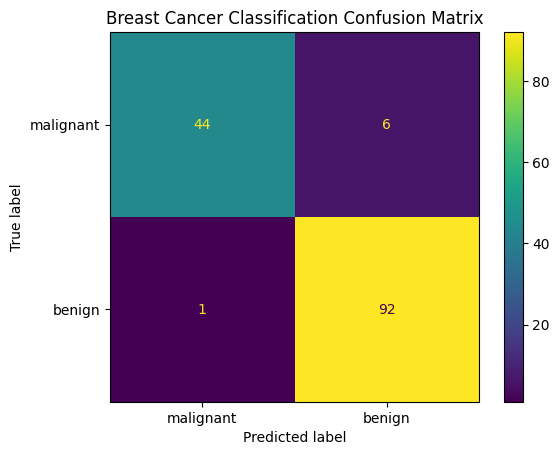

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=breast_cancer.target_names
)

display.plot()
plt.title("Breast Cancer Classification Confusion Matrix")
plt.show()

## K-Fold Cross-Validation

In [15]:
kfold = KFold(
    n_splits=10,
    random_state=11,
    shuffle=True
)

scores = cross_val_score(
    estimator=nb,
    X=breast_cancer.data,
    y=breast_cancer.target,
    cv=kfold
)

print("Cross-validation scores:")
print(scores)

print("Mean accuracy:", scores.mean())
print(f"Mean accuracy percentage: {scores.mean():.2%}")
print("Standard deviation:", scores.std())

Cross-validation scores:
[0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]
Mean accuracy: 0.9384711779448622
Mean accuracy percentage: 93.85%
Standard deviation: 0.02750305414538902


## Running Multiple Models to Find the Best One

In [16]:
estimators = {
    'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(
        solver='lbfgs',
        max_iter=10000
    ),
    'SVC': SVC(gamma='scale')
}

In [17]:
for estimator_name, estimator_object in estimators.items():
    scores = cross_val_score(
        estimator=estimator_object,
        X=breast_cancer.data,
        y=breast_cancer.target,
        cv=kfold
    )

    print(estimator_name)
    print(f"Mean accuracy: {scores.mean():.2%}")
    print(f"Standard deviation: {scores.std():.2%}")
    print()

GaussianNB
Mean accuracy: 93.85%
Standard deviation: 2.75%

KNeighborsClassifier
Mean accuracy: 92.79%
Standard deviation: 2.01%

LogisticRegression
Mean accuracy: 95.08%
Standard deviation: 3.02%

SVC
Mean accuracy: 91.92%
Standard deviation: 3.52%

